In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

In [3]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

versions known to work - 
matplotlib: 3.4.2
numpy: 1.20.3
scipy: 1.4.1
pandas: 1.5.3
seaborn: 0.12.2
allensdk: 2.16.2

In [4]:
import matplotlib
print('matplotlib:', matplotlib.__version__)
import numpy
print('numpy:', numpy.__version__)
import scipy
print('scipy:', scipy.__version__)
import pandas 
print('pandas:', pandas.__version__)
import seaborn
print('seaborn:', seaborn.__version__)
import allensdk
print('allensdk:', allensdk.__version__)

matplotlib: 3.4.2
numpy: 1.22.0
scipy: 1.4.1
pandas: 1.5.3
seaborn: 0.13.0
allensdk: 2.16.2


In [5]:
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

In [6]:
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

### load experiments and cells tables

In [ ]:
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = VisualBehaviorOphysProjectCache.from_local_cache(cache_dir=platform_cache_dir, use_static_cache=True)

ophys_experiment_table = cache.get_ophys_experiment_table()
ophys_experiment_table = utilities.add_extra_columns_to_experiment_table(ophys_experiment_table)
ophys_cells_table = cache.get_ophys_cells_table()
ophys_cells_table = ophys_cells_table.merge(ophys_experiment_table, on='ophys_experiment_id')
print(len(ophys_experiment_table))

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


1936


In [8]:
# metadata tables
experiments_table = pd.read_csv(os.path.join(platform_cache_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# get lists of matched cells and expts
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# get cre_lines and cell types for plot labels
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utilities.get_cell_types_dict(cre_lines, platform_experiments)

# get GLM results
results_pivoted = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'across_session_normalized_platform_results_pivoted.h5'), key='df')
cluster_meta = pd.read_hdf(os.path.join(platform_cache_dir, 'clustering', 'cluster_metadata_'+str(14)+'_clusters.h5'), key='df')


In [9]:
print(len(experiments_table.mouse_id.unique()), 'mice')
print(len(experiments_table.ophys_container_id.unique()), 'containers')
print(len(experiments_table.index.unique()), 'experiments')

107 mice
326 containers
1936 experiments


In [10]:
print(len(platform_experiments.mouse_id.unique()), 'mice')
print(len(platform_experiments.ophys_container_id.unique()), 'containers')
print(len(platform_experiments.index.unique()), 'experiments')

66 mice
134 containers
402 experiments


### Loop through multiscope experiments and aggregate cell specimen table

In [11]:
# for one
ophys_experiment_id = experiments_table.index.values[0]
dataset = cache.get_behavior_ophys_experiment(ophys_experiment_id)
cell_specimen_table = dataset.cell_specimen_table.copy()
cell_specimen_table['roi_size'] = [np.sum(roi_mask) for roi_mask in cell_specimen_table.roi_mask.values]
cell_specimen_table['roi_width_over_height'] = [cell_specimen_table.iloc[i].width/cell_specimen_table.iloc[i].height for i in range(len(cell_specimen_table))]
cell_specimen_table['ophys_experiment_id'] = ophys_experiment_id

In [12]:
meso_experiments = experiments_table[experiments_table.project_code=='VisualBehaviorMultiscope']
len(meso_experiments)

862

In [13]:
save_dir = loading.get_platform_analysis_cache_dir()
save_dir = os.path.join(save_dir, 'cell_specimen_tables')

In [14]:
len(meso_experiments)

862

In [15]:
# all_cell_specimen_table = pd.DataFrame()
# for i, ophys_experiment_id in enumerate(meso_experiments.index.values):
#     filepath = os.path.join(save_dir, str(ophys_experiment_id)+'.csv')
#     if os.path.exists(filepath): 
#         print('file already saved at', filepath)
#     else:
#         print(i, 'out of', len(meso_experiments), 'experiments')
#         dataset = cache.get_behavior_ophys_experiment(ophys_experiment_id)
#         cell_specimen_table = dataset.cell_specimen_table.copy()
#         cell_specimen_table = cell_specimen_table.reset_index()
#         cell_specimen_table['roi_size'] = [np.sum(roi_mask) for roi_mask in cell_specimen_table.roi_mask.values]
#         cell_specimen_table['roi_width_over_height'] = [cell_specimen_table.iloc[c].width/cell_specimen_table.iloc[c].height for c in range(len(cell_specimen_table))]
#         cell_specimen_table['ophys_experiment_id'] = ophys_experiment_id
#         cell_specimen_table.to_csv(filepath)
        

#### Load and save as a single file

In [16]:

# all_cell_specimen_table = pd.DataFrame()
# for i, ophys_experiment_id in enumerate(meso_experiments.index.values):
#     print(i, 'out of', len(meso_experiments), 'experiments')
#     cell_specimen_table = pd.read_csv(os.path.join(save_dir, str(ophys_experiment_id)+'.csv'))

#     all_cell_specimen_table = pd.concat([all_cell_specimen_table, cell_specimen_table])

In [17]:
# cells = all_cell_specimen_table.copy()
# cells = cells.drop(columns=['max_correction_up', 'max_correction_right', 'max_correction_left', 'max_correction_down', 'mask_image_plane', 'Unnamed: 0', 'valid_roi'])
# cells = cells.merge(platform_experiments, on='ophys_experiment_id')
# cells.columns

In [18]:
# # save as one big file
# cells.to_csv(os.path.join(save_dir, 'meso_cell_specimen_table.csv'))

#### Just load the single file

In [19]:
cells = pd.read_csv(os.path.join(save_dir, 'meso_cell_specimen_table.csv'), index_col=0)

In [20]:
cells

,cell_specimen_id,cell_roi_id,height,width,x,y,roi_mask,roi_size,roi_width_over_height,ophys_experiment_id,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
0,1086619317,1080747473,23,15,375,326,[[False False False ... False False False]\n [...,222,0.652174,956941846,...,upper,VISp_upper,20190926,False,-1.0,True,True,False,False,Familiar 3
1,1086619649,1080747476,18,17,172,277,[[False False False ... False False False]\n [...,236,0.944444,956941846,...,upper,VISp_upper,20190926,False,-1.0,True,True,False,False,Familiar 3
2,1086619511,1080747479,24,16,122,279,[[False False False ... False False False]\n [...,236,0.666667,956941846,...,upper,VISp_upper,20190926,False,-1.0,True,True,False,False,Familiar 3
3,1086620671,1080747500,19,25,159,234,[[False False False ... False False False]\n [...,290,1.315789,956941846,...,upper,VISp_upper,20190926,False,-1.0,True,True,False,False,Familiar 3
4,1086620900,1080747506,21,16,96,219,[[False False False ... False False False]\n [...,228,0.761905,956941846,...,upper,VISp_upper,20190926,False,-1.0,True,True,False,False,Familiar 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13352,1120105024,1115429455,21,25,426,459,[[False False False ... False False False]\n [...,384,1.190476,1085840420,...,lower,VISl_lower,20210222,False,2.0,False,False,False,True,Novel 2
13353,1120104540,1115429460,19,31,261,344,[[False False False ... False False False]\n [...,385,1.631579,1085840420,...,lower,VISl_lower,20210222,False,2.0,False,False,False,True,Novel 2
13354,1120095186,1115429462,23,17,62,58,[[False False False ... False False False]\n [...,225,0.739130,1085840420,...,lower,VISl_lower,20210222,False,2.0,False,False,False,True,Novel 2
13355,1120105899,1115429464,15,16,289,290,[[False False False ... False False False]\n [...,137,1.066667,1085840420,...,lower,VISl_lower,20210222,False,2.0,False,False,False,True,Novel 2


#### Evaluate cells

In [21]:
cell_specimen_id = cells.cell_specimen_id.unique()[0]
matched_cell = 1086515505
poorly_matched = 1086516100

In [22]:
cells[cells.cell_specimen_id==matched_cell]

,cell_specimen_id,cell_roi_id,height,width,x,y,roi_mask,roi_size,roi_width_over_height,ophys_experiment_id,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
6071,1086515505,1080837082,14,15,38,138,[[False False False ... False False False]\n [...,155,1.071429,873970527,...,upper,VISp_upper,20190521,False,-1.0,True,True,False,False,Familiar 2
6163,1086515505,1080840146,14,14,34,151,[[False False False ... False False False]\n [...,159,1.000000,877669817,...,upper,VISp_upper,20190522,True,0.0,False,False,False,False,Novel 0
6258,1086515505,1080832317,13,14,34,144,[[False False False ... False False False]\n [...,148,1.076923,877057344,...,upper,VISp_upper,20190528,False,1.0,False,False,True,True,Novel 1


In [23]:
cells[cells.cell_specimen_id==poorly_matched]

,cell_specimen_id,cell_roi_id,height,width,x,y,roi_mask,roi_size,roi_width_over_height,ophys_experiment_id,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
249,1086516100,1080695604,17,23,145,212,[[False False False ... False False False]\n [...,274,1.352941,989213060,...,upper,VISp_upper,20191121,False,-2.0,False,True,False,False,Familiar 1
739,1086516100,1080671564,16,22,158,201,[[False False False ... False False False]\n [...,238,1.375000,990400778,...,upper,VISp_upper,20191125,True,0.0,False,False,False,False,Novel 0
1153,1086516100,1080675319,15,21,170,209,[[False False False ... False False False]\n [...,236,1.400000,991852002,...,upper,VISp_upper,20191202,False,2.0,False,False,False,True,Novel 3


## Compare cell sizes across cre lines & depths

roi_size, roi_width_over_height

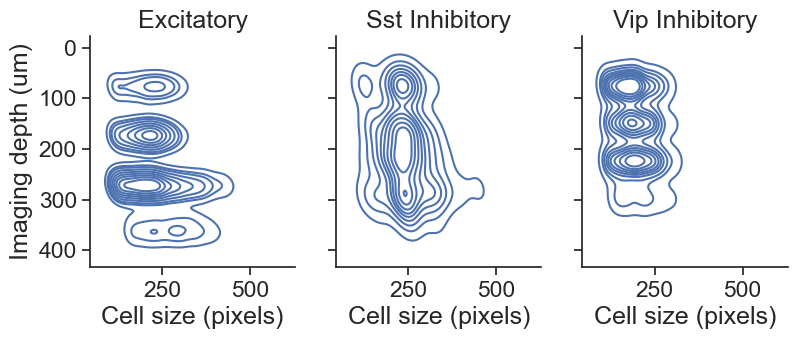

In [24]:
figsize = (9, 3)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True, sharex=True)

for i, cell_type in enumerate(utils.get_cell_types()):
    ct_cells = cells[cells.cell_type==cell_type]
    ax[i] = sns.kdeplot(data=ct_cells, y='imaging_depth', x='roi_size', ax=ax[i])
    ax[i].set_title(cell_type)
    ax[i].invert_yaxis()
    ax[i].set_xlabel('Cell size (pixels)')
    ax[i].set_ylabel('Imaging depth (um)')

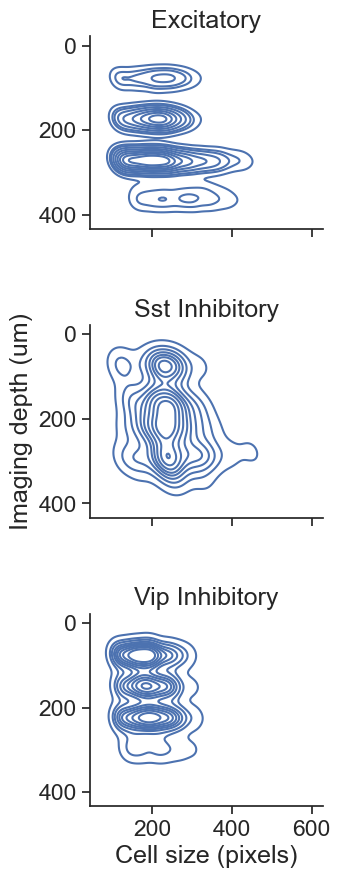

In [28]:
figsize = (3, 10)
fig, ax = plt.subplots(3, 1, figsize=figsize, sharey=True, sharex=True)

for i, cell_type in enumerate(utils.get_cell_types()):
    ct_cells = cells[cells.cell_type==cell_type]
    ax[i] = sns.kdeplot(data=ct_cells, y='imaging_depth', x='roi_size', ax=ax[i])
    ax[i].set_title(cell_type)
    ax[i].invert_yaxis()
    ax[i].set_xlabel('Cell size (pixels)')
    ax[i].set_ylabel('')
ax[1].set_ylabel('Imaging depth (um)')
plt.subplots_adjust(hspace=0.5)

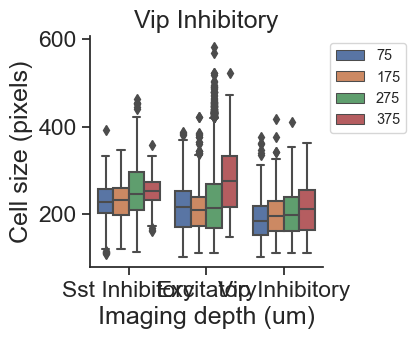

In [25]:
figsize = (3, 3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.boxplot(data=cells, x='cell_type', y='roi_size', hue='binned_depth', ax=ax)
ax.set_title(cell_type)
ax.set_ylabel('Cell size (pixels)')
ax.set_xlabel('Imaging depth (um)')
ax.legend(bbox_to_anchor=(1,1), fontsize='xx-small')

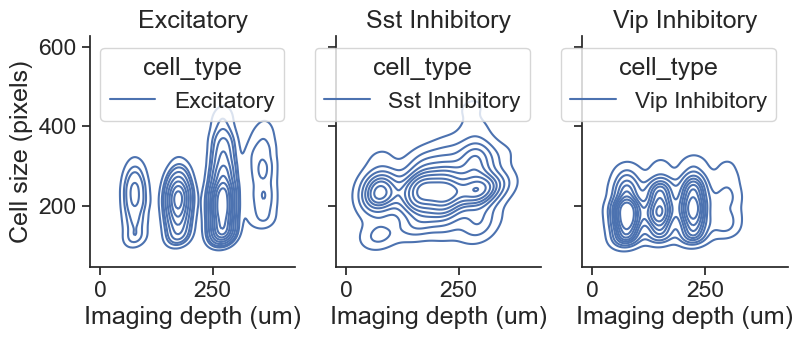

In [26]:
figsize = (9, 3)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True, sharex=True)

for i, cell_type in enumerate(utils.get_cell_types()):
    ct_cells = cells[cells.cell_type==cell_type]
    ax[i] = sns.kdeplot(data=ct_cells, x='imaging_depth', y='roi_size', hue='cell_type', ax=ax[i])
    ax[i].set_title(cell_type)
    ax[i].set_ylabel('Cell size (pixels)')
    ax[i].set_xlabel('Imaging depth (um)')
    ax[i].get_legend().remove()

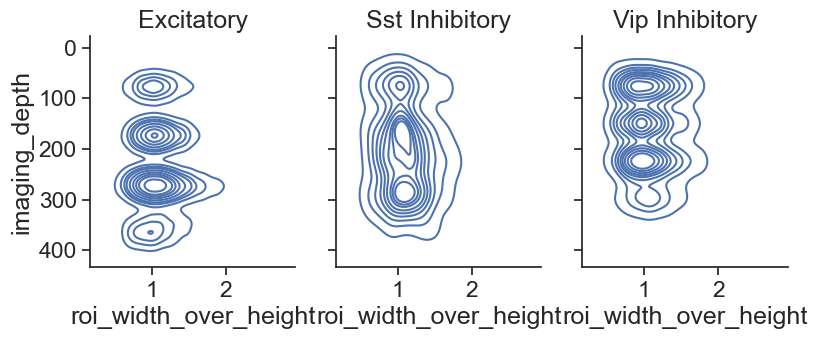

In [27]:
figsize = (9, 3)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True, sharex=True)

for i, cell_type in enumerate(utils.get_cell_types()):
    ct_cells = cells[cells.cell_type==cell_type]
    ax[i] = sns.kdeplot(data=ct_cells, y='imaging_depth', x='roi_width_over_height', ax=ax[i])
    ax[i].set_title(cell_type)
    ax[i].invert_yaxis()

## Compare matched cells over days

In [28]:
matched_cells = cells[cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]

### Compare cell sizes over days

In [29]:
std = matched_cells.groupby(['cell_specimen_id']).std()
mean = matched_cells.groupby(['cell_specimen_id']).mean()

C:\Users\marinag\AppData\Local\Temp\ipykernel_8004\2185837733.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  std = matched_cells.groupby(['cell_specimen_id']).std()
C:\Users\marinag\AppData\Local\Temp\ipykernel_8004\2185837733.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean = matched_cells.groupby(['cell_specimen_id']).mean()


Text(0, 0.5, 'count')

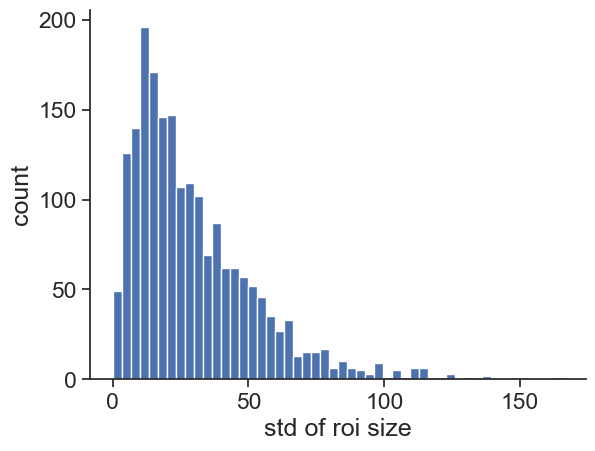

In [30]:
plt.hist(std['roi_size'], bins=50);
plt.xlabel('std of roi size')
plt.ylabel('count')

### Plot masks across sessions for cells with similar size across days

In [ ]:
small_diff_cells = std[std.roi_size<20].index.unique()

for cell_specimen_id in small_diff_cells[:20]:

    cell_metadata = matched_cells_table[matched_cells_table.cell_specimen_id==cell_specimen_id]
    cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id]

    pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, save_dir=save_dir)


cell_specimen_id: 1086501719
experience_level: Familiar
ophys_experiment_id: 847267622


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


experience_level: Novel
ophys_experiment_id: 849233396


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


experience_level: Novel +
ophys_experiment_id: 851085100


...

saving plot for 1086503200
saved
cell_specimen_id: 1086504629
experience_level: Familiar
ophys_experiment_id: 873970535


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


experience_level: Novel
ophys_experiment_id: 877669826


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


experience_level: Novel +
ophys_experiment_id: 877057357


### Plot masks across sessions for cells with high standard deviation in cell volume

In [32]:
big_diff_cells = std[std.roi_size>50].index.unique()

In [33]:
# for cell_specimen_id in big_diff_cells[:8]:

#     cell_metadata = matched_cells_table[matched_cells_table.cell_specimen_id==cell_specimen_id]
#     cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id]

#     pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, save_dir=save_dir)


### Compare aspect ratio over days

Text(0, 0.5, 'count')

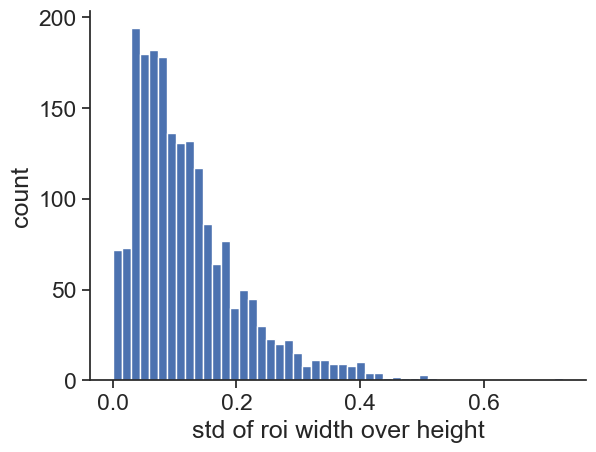

In [34]:
plt.hist(std['roi_width_over_height'], bins=50);
plt.xlabel('std of roi width over height')
plt.ylabel('count')

### Plot masks across sessions for cells with similar aspect ratio across days

In [35]:
# small_diff_cells = std[std.roi_width_over_height<0.1].index.unique()

# for cell_specimen_id in small_diff_cells[:8]:

#     cell_metadata = matched_cells_table[matched_cells_table.cell_specimen_id==cell_specimen_id]
#     cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id]

#     pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, save_dir=save_dir)


### Plot masks across sessions for cells with large difference in aspect ratio across days

In [37]:
# small_diff_cells = std[std.roi_width_over_height>0.2].index.unique()

# for cell_specimen_id in small_diff_cells[:8]:

#     cell_metadata = matched_cells_table[matched_cells_table.cell_specimen_id==cell_specimen_id]
#     cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id]

#     pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, save_dir=save_dir)
